In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_12_png.rf.566726d03bb59741293c5a5c58d71f5e_aug_2.jpg
/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_45_png.rf.7b0c39c7948b368961c4bbc376c93d99.jpg
/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_43_png.rf.225187fb6b8111d171ffcccb2e905e3a_aug_0.jpg
/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_50_png.rf.15b257af83325aa3721cf4463a3ce1b8_aug_1.jpg
/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_47_png.rf.96ba9988494f51b9f661609792706976_aug_0.jpg
/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/Augumented/Augumented/augmented_stage2/t

In [3]:
import warnings
warnings.filterwarnings("ignore")

Download required libraries

In [4]:
!pip install --upgrade -q grad-cam
!pip install ptflops psutil
!pip install onnxscript
!pip install onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.0 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 85.3 MB/s eta 0:00:00:00:0100:01


Train the model over resnet18

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, f1_score, accuracy_score

# -----------------
# Config
# -----------------
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------
# Transforms
# -----------------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder("/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/stage2/train/", transform=transform)
val_dataset   = datasets.ImageFolder("/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/stage2/valid/", transform=transform)
test_dataset = datasets.ImageFolder("/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/stage2/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader   = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
# -----------------
# Model
# -----------------
model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# -----------------
# Training Loop
# -----------------
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

torch.save(model, "ResNet18_model_full.pth")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 151MB/s] 


Epoch 1, Loss: 16.3110
Epoch 2, Loss: 2.1489
Epoch 3, Loss: 0.7028
Epoch 4, Loss: 0.3865
Epoch 5, Loss: 0.2860
Epoch 6, Loss: 0.1892
Epoch 7, Loss: 0.1213
Epoch 8, Loss: 0.1815
Epoch 9, Loss: 0.0666
Epoch 10, Loss: 0.0991


Evaluate the model

In [6]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Metrics
acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

Accuracy: 0.8553
F1 Score: 0.8541
               precision    recall  f1-score   support

          LER       0.89      0.80      0.84        10
        crack       0.90      0.82      0.86        11
malformed_via       0.78      0.70      0.74        10
         open       0.81      0.96      0.88        26
        short       0.94      0.84      0.89        19

     accuracy                           0.86        76
    macro avg       0.86      0.82      0.84        76
 weighted avg       0.86      0.86      0.85        76



using Grad-CAM

In [7]:
 def evaluate_model(heatmaps, masks):
    iou_list = []
    activation_list = []

    for heatmap, mask in zip(heatmaps, masks):
        metrics = compute_metrics(heatmap, mask)
        iou_list.append(metrics["IoU"])
        activation_list.append(metrics["Activation_Ratio"])

    return {
        "Mean IoU": np.mean(iou_list),
        "Mean Activation Ratio": np.mean(activation_list)
    }

In [8]:
def compute_metrics(heatmap, gt_mask, threshold=0.5):
    """
    heatmap: Grad-CAM output (H x W)
    gt_mask: Ground truth binary mask (H x W)
    """

    # Normalize
    heatmap = normalize_heatmap(heatmap)
    heatmap = resize_to_match(heatmap, gt_mask)

    # Threshold heatmap
    binary_map = (heatmap >= threshold).astype(np.uint8)

    # Intersection and Union
    intersection = np.logical_and(binary_map, gt_mask).sum()
    union = np.logical_or(binary_map, gt_mask).sum()

    iou = intersection / (union + 1e-8)

    # Activation inside defect
    inside_activation = heatmap[gt_mask == 1].sum()
    total_activation = heatmap.sum()

    activation_ratio = inside_activation / (total_activation + 1e-8)

    return {
        "IoU": iou,
        "Activation_Ratio": activation_ratio
    }

In [9]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# -----------------------
# 1️⃣ Load Model
# -----------------------

#model = torch.load("model_full.pth", weights_only=False)
model.eval()

# Enable gradients (IMPORTANT for Grad-CAM)
for param in model.parameters():
    param.requires_grad = True

# -----------------------
# 2️⃣ Setup Grad-CAM
# -----------------------

target_layer = model.layer4[-1] #specific to resnet
cam = GradCAM(model=model, target_layers=[target_layer])

# -----------------------
# 3️⃣ Output Root
# -----------------------

output_root = "structured_gradcam"
os.makedirs(output_root, exist_ok=True)

class_names = test_dataset.classes
num_classes = len(class_names)

# -----------------------
# 4️⃣ Loop Over Entire Test Dataset
# -----------------------

for idx in range(len(test_dataset)):

    img, label = test_dataset[idx]
    true_class = class_names[label]

    # Create folder for TRUE class
    true_class_folder = os.path.join(output_root, f"True_{true_class}")
    os.makedirs(true_class_folder, exist_ok=True)

    # Create subfolder per image
    image_folder = os.path.join(true_class_folder, f"image_{idx}")
    os.makedirs(image_folder, exist_ok=True)

    input_tensor = img.unsqueeze(0).to(0)

    # Prepare image for overlay
    rgb_img = img.permute(1, 2, 0).cpu().numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

    # -----------------------
    # 5️⃣ Generate CAM for ALL classes
    # -----------------------

    for class_idx in range(num_classes):

        target_class_name = class_names[class_idx]

        targets = [ClassifierOutputTarget(class_idx)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0]

        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        save_path = os.path.join(
            image_folder,
            f"cam_{target_class_name}.png"
        )

        plt.imsave(save_path, visualization)

print("Structured Grad-CAM generation completed.")

Structured Grad-CAM generation completed.


In [17]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# -----------------------
# 1️⃣ Load Model
# -----------------------

# model = torch.load("model_full.pth", weights_only=False)
model.eval()

# Enable gradients (IMPORTANT)
for param in model.parameters():
    param.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# -----------------------
# 2️⃣ Setup Grad-CAM
# -----------------------
#target_layers = model.layer4[-1] #specific to resnet
target_layers = [model.layer4[-1]]  # ✅ CORRECT

cam = GradCAM(model=model, target_layers=target_layers)

# -----------------------
# 3️⃣ Output Root
# -----------------------

output_root = "structured_gradcam"
os.makedirs(output_root, exist_ok=True)

class_names = test_dataset.classes
num_classes = len(class_names)

# -----------------------
# ✅ 4️⃣ Metric Functions
# -----------------------

def normalize_heatmap(heatmap):
    heatmap = np.maximum(heatmap, 0)
    return heatmap / (heatmap.max() + 1e-8)

def resize_to_match(heatmap, mask):
    return cv2.resize(heatmap, (mask.shape[1], mask.shape[0]))

def compute_metrics(heatmap, gt_mask, threshold=0.5):
    heatmap = normalize_heatmap(heatmap)
    heatmap = resize_to_match(heatmap, gt_mask)

    binary_map = (heatmap >= threshold).astype(np.uint8)

    intersection = np.logical_and(binary_map, gt_mask).sum()
    union = np.logical_or(binary_map, gt_mask).sum()
    iou = intersection / (union + 1e-8)

    inside_activation = heatmap[gt_mask == 1].sum()
    total_activation = heatmap.sum()
    activation_ratio = inside_activation / (total_activation + 1e-8)

    return {"IoU": iou, "Activation_Ratio": activation_ratio}


def evaluate_model(heatmaps, masks):
    iou_list = []
    activation_list = []

    for heatmap, mask in zip(heatmaps, masks):
        metrics = compute_metrics(heatmap, mask)
        iou_list.append(metrics["IoU"])
        activation_list.append(metrics["Activation_Ratio"])

    return {
        "Mean IoU": np.mean(iou_list),
        "Mean Activation Ratio": np.mean(activation_list)
    }

# -----------------------
# ✅ 5️⃣ Storage for Metrics
# -----------------------

heatmaps = []
masks = []

# -----------------------
# 6️⃣ Loop Over Dataset
# -----------------------

for idx in range(len(test_dataset)):

    img, label = test_dataset[idx]
    true_class = class_names[label]

    # Create folders
    true_class_folder = os.path.join(output_root, f"True_{true_class}")
    os.makedirs(true_class_folder, exist_ok=True)

    image_folder = os.path.join(true_class_folder, f"image_{idx}")
    os.makedirs(image_folder, exist_ok=True)

    input_tensor = img.unsqueeze(0).to(device)

    # Prepare image for visualization
    rgb_img = img.permute(1, 2, 0).cpu().numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min() + 1e-8)

    # -----------------------
    # ✅ Predict Class
    # -----------------------

    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()
    pred_class_name = class_names[pred_class]
    # -----------------------
    # ✅ Grad-CAM for predicted class (FOR METRICS)
    # -----------------------

    targets = [ClassifierOutputTarget(pred_class)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]

    # Store heatmap
    heatmaps.append(grayscale_cam)

    # -----------------------
    # ✅ Create Mask (if no GT mask)
    # -----------------------

    gray = cv2.cvtColor((rgb_img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 50, 1, cv2.THRESH_BINARY)

    masks.append(mask)

    # -----------------------
    # 7️⃣ Save CAM for ALL classes (for visualization)
    # -----------------------

    for class_idx in range(num_classes):

        target_class_name = class_names[class_idx]

        targets = [ClassifierOutputTarget(class_idx)]
        cam_all = cam(input_tensor=input_tensor, targets=targets)
        cam_all = cam_all[0]

        visualization = show_cam_on_image(rgb_img, cam_all, use_rgb=True)

        save_path = os.path.join(image_folder, f"cam_predicted_{pred_class_name}.png")
        

        plt.imsave(save_path, visualization)

# -----------------------
# ✅ 8️⃣ Compute Metrics
# -----------------------

print(f"Processed {len(heatmaps)} images")

metrics = evaluate_model(heatmaps, masks)

print("\nGrad-CAM Metrics:")
print("Mean IoU:", round(metrics["Mean IoU"], 4))
print("Mean Activation Ratio:", round(metrics["Mean Activation Ratio"], 4))

Processed 81 images

Grad-CAM Metrics:
Mean IoU: 0.3576
Mean Activation Ratio: 0.823


Store the result

In [18]:
    import shutil

    shutil.make_archive(
        base_name="/kaggle/working/Resnet18_structured_gradcam_results",
        format="zip",
        root_dir="/kaggle/working/structured_gradcam"
    )

    print("Zip file created successfully!")

Zip file created successfully!


In [22]:
import os
import cv2
import numpy as np
import pandas as pd
import random
from IPython.display import display, HTML

root_dir = "structured_gradcam"

rows = []

class_folders = [f for f in os.listdir(root_dir) if f.startswith("True_")]
class_names = [f.replace("True_", "") for f in class_folders]

for class_folder in class_folders:

    class_path = os.path.join(root_dir, class_folder)
    true_class = class_folder.replace("True_", "")

    image_folders = os.listdir(class_path)
    if len(image_folders) == 0:
        continue

    # ✅ Pick random image
    image_folder = random.choice(image_folders)
    image_path = os.path.join(class_path, image_folder)

    row = {
        "True Class": true_class,
    }

    max_score = -1
    pred_class = None

    # -----------------------
    # Collect all CAMs
    # -----------------------
    for class_name in class_names:
        cam_file = f"cam_{class_name}.png"
        cam_path = os.path.join(image_path, cam_file)

        if os.path.exists(cam_path):
            # Convert to HTML image
            row[class_name] = f'<img src="{cam_path}" width="120"/>'

            # Find predicted class (max activation)
            img = cv2.imread(cam_path)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            score = np.mean(gray)

            if score > max_score:
                max_score = score
                pred_class = class_name
        else:
            row[class_name] = ""

    row["Predicted Class"] = pred_class

    rows.append(row)

# -----------------------
# Create DataFrame
# -----------------------
df = pd.DataFrame(rows)

# Reorder columns
df = df[["True Class", "Predicted Class"] + class_names]

# Display as HTML (important)
display(HTML(df.to_html(escape=False)))

,True Class,Predicted Class,malformed_via,crack,short,open,LER
0,malformed_via,malformed_via,,,,,
1,crack,crack,,,,,
2,short,LER,,,,,
3,open,short,,,,,
4,LER,LER,,,,,


In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(0)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = test_dataset.classes

In [12]:
accuracy = np.mean(all_preds == all_labels)
print("Overall Accuracy:", accuracy)

Overall Accuracy: 0.8024691358024691


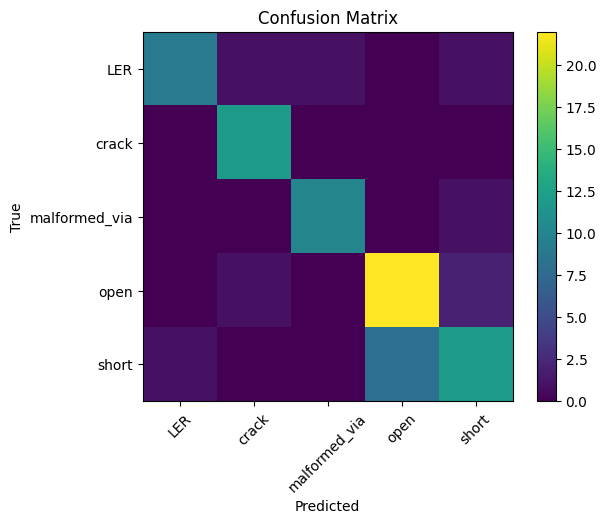

In [15]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
plt.imshow(cm)
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

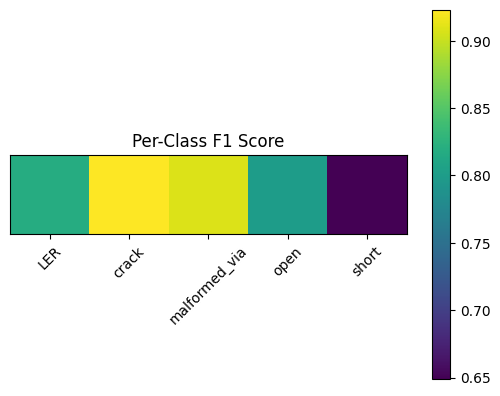

In [16]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True
)

f1_scores = [report[c]["f1-score"] for c in class_names]

plt.figure()
plt.imshow(np.array(f1_scores).reshape(1, -1))
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks([])
plt.title("Per-Class F1 Score")
plt.colorbar()
plt.show()

Edge suitability check over trained model

In [17]:
import torch
import time
import os
import psutil
from ptflops import get_model_complexity_info

MODEL_PATH = "/kaggle/working/model_full.pth"

# ----------------------------
# Device setup
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Load model
# ----------------------------
model = torch.load(MODEL_PATH, weights_only=False)
model = model.to(0)
model.eval()

print("\n===== MODEL BENCHMARK =====\n")

# ----------------------------
# Model size
# ----------------------------
model_size = os.path.getsize(MODEL_PATH)/(1024*1024)
print("Model size:", round(model_size,2), "MB")

# ----------------------------
# Parameter count
# ----------------------------
params = sum(p.numel() for p in model.parameters())
print("Parameters:", params)

# ----------------------------
# FLOPs
# ----------------------------
macs, _ = get_model_complexity_info(
    model,
    (3,224,224),
    as_strings=False,
    print_per_layer_stat=False
)

flops = macs * 2

print("FLOPs:", round(flops/1e6,2), "MFLOPs")

# ----------------------------
# Inference latency
# ----------------------------
dummy = torch.randn(1,3,224,224).to(device)

# warmup
for _ in range(10):
    model(dummy)

runs = 100

start = time.time()

with torch.no_grad():
    for _ in range(runs):
        model(dummy)

end = time.time()

latency = (end-start)/runs*1000
fps = 1000/latency

print("Latency:", round(latency,2), "ms")
print("Throughput:", round(fps,2), "FPS")

# ----------------------------
# Memory usage
# ----------------------------
process = psutil.Process(os.getpid())
memory = process.memory_info().rss/(1024*1024)

print("RAM usage:", round(memory,2), "MB")

# ----------------------------
# Edge suitability score
# ----------------------------
score = 0

if model_size < 10:
    score += 1
if params < 5_000_000:
    score += 1
if latency < 50:
    score += 1
if flops < 500e6:
    score += 1

levels = ["Poor","Moderate","Good","Excellent"]

print("\nEdge suitability:", levels[score-1] if score>0 else "Poor")


===== MODEL BENCHMARK =====

Model size: 42.73 MB
Parameters: 11179077
FLOPs: 3649.61 MFLOPs
Latency: 2.67 ms
Throughput: 374.66 FPS
RAM usage: 1652.47 MB

Edge suitability: Poor


Convert the trained model to onnx 

In [19]:
import torch.onnx

model = model.to("cpu")
model.eval()

dummy_input = torch.randn(1, 3, 224, 224)

torch.onnx.export(
    model,
    dummy_input,
    "resnet18_fp32.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=13,
    dynamo=False   # 🔥 important
)

Sanity check after ONNX conversion model performance is not degraded

In [20]:
import onnxruntime as ort
import numpy as np

session = ort.InferenceSession("resnet18_fp32.onnx")

# same dummy input
torch_out = model(dummy_input).detach().numpy()
onnx_out = session.run(None, {"input": dummy_input.numpy()})

print("Torch:", torch_out[0][:5])
print("ONNX :", onnx_out[0][0][:5])

print("Torch pred:", np.argmax(torch_out))
print("ONNX pred :", np.argmax(onnx_out[0]))

Torch: [-2.7941582   0.44252172  0.20244007  1.5845587   2.2127357 ]
ONNX : [-2.794159    0.4425216   0.20243958  1.584559    2.212735  ]
Torch pred: 4
ONNX pred : 4


Dynamically Quantise the model (INT8)

In [21]:
from onnxruntime.quantization import quantize_dynamic, QuantType

quantize_dynamic(
    model_input="resnet18_fp32.onnx",
    model_output="resnet18_int8.onnx",
    weight_type=QuantType.QInt8
)

Check the edge suitability over Quantised model

In [22]:
import onnx
import onnxruntime as ort
import numpy as np
import time
import os
import psutil

MODEL_PATH = "/kaggle/working/resnet18_int8.onnx"

print("\n===== Quantise ONNX MODEL BENCHMARK =====\n")

# ----------------------------
# Model size
# ----------------------------
model_size = os.path.getsize(MODEL_PATH)/(1024*1024)
print("Model size:", round(model_size,2), "MB")

# ----------------------------
# Load ONNX model
# ----------------------------
session = ort.InferenceSession(MODEL_PATH)

input_name = session.get_inputs()[0].name
input_shape = session.get_inputs()[0].shape

print("Input shape:", input_shape)

# ----------------------------
# Parameter count (approx)
# ----------------------------
onnx_model = onnx.load(MODEL_PATH)

param_count = 0
for tensor in onnx_model.graph.initializer:
    param_count += np.prod(tensor.dims)

print("Parameters:", int(param_count))

# ----------------------------
# FLOPs (approx using onnx tool)
# ----------------------------
try:
    from onnx_tool import model_profile

    profile = model_profile(onnx_model)
    flops = profile["flops"]

    print("FLOPs:", round(flops/1e6,2), "MFLOPs")

except:
    print("FLOPs: Install 'onnx-tool' for FLOPs calculation")

# ----------------------------
# Inference latency
# ----------------------------
dummy = np.random.randn(1,3,224,224).astype(np.float32)

# warmup
for _ in range(10):
    session.run(None, {input_name: dummy})

runs = 100

start = time.time()

for _ in range(runs):
    session.run(None, {input_name: dummy})

end = time.time()

latency = (end-start)/runs*1000
fps = 1000/latency

print("Latency:", round(latency,2), "ms")
print("Throughput:", round(fps,2), "FPS")

# ----------------------------
# Memory usage
# ----------------------------
process = psutil.Process(os.getpid())
memory = process.memory_info().rss/(1024*1024)

print("RAM usage:", round(memory,2), "MB")

# ----------------------------
# Edge suitability score
# ----------------------------
score = 0

if model_size < 10:
    score += 1
if param_count < 5_000_000:
    score += 1
if latency < 50:
    score += 1
if 'flops' in locals() and flops < 500e6:
    score += 1



levels = ["Poor","Moderate","Good","Excellent"]

print("\nEdge suitability:", levels[score-1] if score>0 else "Poor")
#print("score",score )


===== Quantise ONNX MODEL BENCHMARK =====

Model size: 10.71 MB
Input shape: [1, 3, 224, 224]
Parameters: 11174399
FLOPs: Install 'onnx-tool' for FLOPs calculation
Latency: 128.71 ms
Throughput: 7.77 FPS
RAM usage: 1890.49 MB

Edge suitability: Poor
